# Ingredient Detection - YOLOv11 with Built-in Augmentation

End-to-end training notebook for the 207-class ingredients dataset.
Augmentation is woven into the pipeline from the start:

1. **Offline pre-augmentation**: expands the training set on disk before any
   training begins, using a rich Albumentations pipeline.  Rare classes get
   extra copies automatically.
2. **Online YOLO augmentation**: stronger geometric/mixing params are passed
   directly to `model.train()` so every batch sees additional variation at
   runtime.

Run cells top-to-bottom.  Each section is self-contained and clearly labelled.

## 1. Install dependencies

In [1]:
!pip install --upgrade pip -q
!pip install ultralytics albumentations tqdm --upgrade -q
!pip install torch --index-url https://download.pytorch.org/whl/cu130 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


## 2. Imports & environment check

In [2]:
import os, shutil, random, math
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm
import yaml
import torch
from ultralytics import YOLO

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'albumentations: {A.__version__}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.9.0+cu126
CUDA: True
GPU: Tesla T4
albumentations: 2.0.8


## 3. Paths & global config

In [3]:
# Source dataset (read-only on Kaggle)
DATASET_PATH = Path('/kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset')
OG_YAML      = DATASET_PATH / 'data.yaml'

# Working directories (writable)
WORK_DIR = Path('/kaggle/working')
AUG_DATASET = WORK_DIR / 'aug_dataset' # offline-augmented copy of train
WEIGHTS_DIR = WORK_DIR / 'weights'
DATA_YAML = WORK_DIR / 'data_aug.yaml'

AUG_DATASET.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# Augmentation hyper-parameters
AUG_CFG = dict(
    # How many augmented copies to generate per original image
    copies_per_image = 2,
    # Classes with fewer than this many training instances get extra copies
    rare_class_thresh = 10,
    rare_class_copies = 4,   # total copies for rare-class images
    seed = 42,
)

# YOLO online training config
TRAIN_CFG = dict(
    model = 'yolo11n.pt',
    epochs = 120,
    imgsz = 640,
    batch = 16,
    device = 0 if torch.cuda.is_available() else 'cpu',
    workers = 8,
    patience = 60,
    save = True,
    save_period = 10,
    cache = False,
    optimizer = 'auto',
    lr0 = 0.01,
    lrf = 0.01,
    momentum = 0.937,
    weight_decay = 0.0005,
    warmup_epochs = 3.0,
    warmup_momentum = 0.8,
    warmup_bias_lr = 0.1,
    box = 7.5,
    cls= 0.5,
    dfl = 1.5,
    # colour
    hsv_h = 0.02,
    hsv_s = 0.75,
    hsv_v = 0.45,
    # geometry
    degrees = 10.0, # ±10° rotation
    translate = 0.1,
    scale = 0.5,
    shear = 2.0, # ±2° shear
    perspective = 0.001,  # subtle lens distortion
    flipud = 0.1, # 10% vertical flip (helps top-down shots)
    fliplr = 0.5,
    # mixing / occlusion
    mosaic = 1.0,
    mixup = 0.1,    # blend two images 10% of the time
    copy_paste = 0.1,    # paste instances across images
    erasing = 0.4,    # random rectangular occlusion
    name = 'ingredient_detection_aug',
)

random.seed(AUG_CFG['seed'])
np.random.seed(AUG_CFG['seed'])
print('Config ready.')

Config ready.


## **4. Load dataset YAML**

In [4]:
with open(OG_YAML, 'r') as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg['names'] # list of 207 class names
NC = data_cfg['nc'] # 207

print(f'Classes: {NC}')
print(f'First 5: {CLASS_NAMES[:5]}')
print(f'Last 5: {CLASS_NAMES[-5:]}')


Classes: 207
First 5: ['agar agar powder', 'alsa powder', 'annatto oil', 'bamboo shoot', 'banana']
Last 5: ['wine', 'winter melon', 'wonton', 'wood ear mushroom', 'yeast']


## **5. Albumentations augmentation pipeline**

In [5]:
def build_pipeline(p: float = 0.6) -> A.Compose:
    """
    Bbox-safe augmentation pipeline in YOLO format.

    Designed for food / ingredient photography:
    - Colour transforms simulate different lighting environments
      (market stalls, restaurant kitchens, home counters).
    - Noise / blur mimic phone-camera conditions.
    - Shadow / fog simulate outdoor wet-market scenes.
    - Geometry ops are kept mild to avoid destroying small objects.
    """
    return A.Compose(
        [
            # Colour / lighting
            A.ColorJitter(
                brightness=0.3, contrast=0.3,
                saturation=0.3, hue=0.05, p=p
            ),
            A.HueSaturationValue(
                hue_shift_limit=15, sat_shift_limit=30,
                val_shift_limit=20, p=p
            ),
            A.RandomBrightnessContrast(
                brightness_limit=0.25, contrast_limit=0.25, p=p
            ),
            A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=p * 0.5),
            A.RandomShadow(p=p * 0.3),
            A.RandomFog(fog_coef_range=(0.05, 0.2), p=p * 0.2),

            # Noise / blur
            A.GaussNoise(std_range=(0.012, 0.028), p=p * 0.4),
            A.ISONoise(
                color_shift=(0.01, 0.05),
                intensity=(0.1, 0.5), p=p * 0.3
            ),
            A.OneOf([
                A.MotionBlur(blur_limit=5),
                A.MedianBlur(blur_limit=5),
                A.Blur(blur_limit=5),
            ], p=p * 0.3),

            # Resolution
            A.Downscale(scale_range=(0.5, 0.9), p=p * 0.2),

            # Geometry (bbox-safe)
            A.Affine(
                translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
                scale=(0.9, 1.1), # 1 ± scale_limit
                rotate=(-10, 10),
                border_mode=cv2.BORDER_REFLECT_101,
                p=p
            ),
            A.Perspective(scale=(0.02, 0.05), p=p * 0.3),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.1),
        ],
        bbox_params=A.BboxParams(
            format='yolo',
            label_fields=['class_labels'],
            min_visibility=0.3, # drop boxes that become <30% visible
        )
    )


PIPELINE = build_pipeline(p=0.65)
print('Pipeline built.')


Pipeline built.


## **6. Label I/O helpers**

In [6]:
def read_label(label_path: Path):
    """Return (class_ids: list[int], boxes: list[[cx,cy,w,h]])."""
    class_ids, boxes = [], []
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) == 5:
                class_ids.append(int(parts[0]))
                boxes.append([float(x) for x in parts[1:]])
    return class_ids, boxes


def write_label(label_path: Path, class_ids, boxes):
    """Write YOLO label file from class_ids and boxes."""
    lines = [
        f'{int(cls_id)} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}'
        for cls_id, (cx, cy, bw, bh) in zip(class_ids, boxes)
    ]
    label_path.write_text('\n'.join(lines))


def augment_sample(img_bgr, class_ids, boxes, pipeline):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    out = pipeline(
        image=img_rgb,
        bboxes=boxes,
        class_labels=class_ids,
    )
    # Clamp all bbox coords to [0, 1] to fix floating point epsilon drift
    clean_boxes = [
        tuple(min(1.0, max(0.0, v)) for v in box)
        for box in out['bboxes']
    ]
    return out['image'], list(out['class_labels']), clean_boxes


print('Label helpers ready.')


Label helpers ready.


## **7. Count class frequencies for rare-class oversampling**

In [7]:
src_img_dir = DATASET_PATH / data_cfg['train']
src_lbl_dir = src_img_dir.parent / 'labels'

# Count instances per class across the entire training set
class_instance_count: Counter = Counter()
img_to_classes: dict = {}   # img_stem → set of class ids present

all_train_imgs = sorted(src_img_dir.glob('*.*'))
for img_path in tqdm(all_train_imgs, desc='Scanning labels'):
    lbl_path = src_lbl_dir / (img_path.stem + '.txt')
    class_ids, _ = read_label(lbl_path)
    for cid in class_ids:
        class_instance_count[cid] += 1
    img_to_classes[img_path.stem] = set(class_ids)

# Which classes are rare?
THRESH = AUG_CFG['rare_class_thresh']
rare_classes = {cid for cid, cnt in class_instance_count.items() if cnt < THRESH}
print(f'Total training images : {len(all_train_imgs)}')
print(f'Rare classes (<{THRESH} instances): {len(rare_classes)}')
if rare_classes:
    print('  ' + ', '.join(CLASS_NAMES[c] for c in sorted(rare_classes)))


Scanning labels:   0%|          | 0/3838 [00:00<?, ?it/s]

Total training images : 3838
Rare classes (<10 instances): 3
  beef stock, egg white, rice flour


## **8. Offline augmentation - build augmented training split**

In [8]:
# Output dirs
aug_img_dir = AUG_DATASET / 'train' / 'images'
aug_lbl_dir = AUG_DATASET / 'train' / 'labels'
aug_img_dir.mkdir(parents=True, exist_ok=True)
aug_lbl_dir.mkdir(parents=True, exist_ok=True)

COPIES      = AUG_CFG['copies_per_image']
RARE_COPIES = AUG_CFG['rare_class_copies']
errors      = []

for img_path in tqdm(all_train_imgs, desc='Augmenting train'):
    stem     = img_path.stem
    lbl_path = src_lbl_dir / (stem + '.txt')
    class_ids, boxes = read_label(lbl_path)

    # Decide how many augmented copies to make
    is_rare = bool(img_to_classes.get(stem, set()) & rare_classes)
    n_copies = RARE_COPIES if is_rare else COPIES

    try:
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            raise ValueError('Could not read image')

        # 1. Always copy the original (unchanged)
        dst_img = aug_img_dir / img_path.name
        dst_lbl = aug_lbl_dir / (stem + '.txt')
        shutil.copy2(img_path, dst_img)
        if class_ids:
            write_label(dst_lbl, class_ids, boxes)

        # 2. Generate augmented copies
        for k in range(n_copies):
            aug_img, aug_cls, aug_boxes = augment_sample(
                img_bgr, class_ids, boxes, PIPELINE
            )
            ext     = img_path.suffix
            out_stem = f'{stem}_aug{k}'
            out_img  = aug_img_dir / f'{out_stem}{ext}'
            out_lbl  = aug_lbl_dir / f'{out_stem}.txt'

            cv2.imwrite(
                str(out_img),
                cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)
            )
            if aug_cls:
                write_label(out_lbl, aug_cls, aug_boxes)

    except Exception as e:
        errors.append((img_path.name, str(e)))

total_aug = len(list(aug_img_dir.glob('*.*')))
print(f'\nOriginal images: {len(all_train_imgs)}')
print(f'Augmented total: {total_aug}')
print(f'Expansion factor: {total_aug / max(len(all_train_imgs),1):.1f}x')
if errors:
    print(f'Errors ({len(errors)}):', errors[:5])


Augmenting train:   0%|          | 0/3838 [00:00<?, ?it/s]

libpng warning: eXIf: duplicate
libpng warning: iCCP: profile 'icc': 0h: PCS illuminant is not D50
libpng warning: iCCP: extra compressed data



Original images: 3838
Augmented total: 11462
Expansion factor: 3.0x
Errors (47): [('bamboo shoot_image_8.webp', 'Expected y_min for bbox [ 0.00012448 -5.0664e-07           1     0.99992           3] to be in the range [0.0, 1.0], got -5.066394805908203e-07.'), ('banana leaf_image_12.jpg', 'Expected y_min for bbox [   0.090288 -4.7684e-07           1     0.81118           6] to be in the range [0.0, 1.0], got -4.76837158203125e-07.'), ('banana leaf_image_22.jpg', 'Expected y_min for bbox [   0.005464 -5.0664e-07     0.99928     0.93952           6] to be in the range [0.0, 1.0], got -5.066394805908203e-07.'), ('basil_image_10.jpg', 'Expected y_min for bbox [    0.11398 -5.0664e-07      0.9338     0.99973           7] to be in the range [0.0, 1.0], got -5.066394805908203e-07.'), ('calamari_image_3.jpg', 'Expected x_min for bbox [-5.0664e-07    0.001557     0.99985     0.94387          31] to be in the range [0.0, 1.0], got -5.066394805908203e-07.')]


## **9. Wire up val/test splits & write data YAML**

In [9]:
# Val and test remain the original (no augmentation on eval splits)
for split in ('val', 'test'):
    for kind in ('images', 'labels'):
        src = DATASET_PATH / split / kind
        dst = AUG_DATASET / split / kind
        if dst.exists() or dst.is_symlink():
            pass  # already there
        else:
            dst.parent.mkdir(parents=True, exist_ok=True)
            os.symlink(src.resolve(), dst)

# Write a new data.yaml that points at our augmented dataset
new_yaml = {
    'path': str(AUG_DATASET),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': NC,
    'names': CLASS_NAMES,
}
with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(new_yaml, f, sort_keys=False, allow_unicode=True)

print(f'data YAML written → {DATA_YAML}')

# Quick sanity-check
with open(DATA_YAML) as f:
    check = yaml.safe_load(f)
print(f'train images: {aug_img_dir}')
print(f'val images: {AUG_DATASET / "val" / "images"}')
print(f'nc: {check["nc"]}')

data YAML written → /kaggle/working/data_aug.yaml
train images: /kaggle/working/aug_dataset/train/images
val images: /kaggle/working/aug_dataset/val/images
nc: 207


## 10. Visualise a few augmented samples

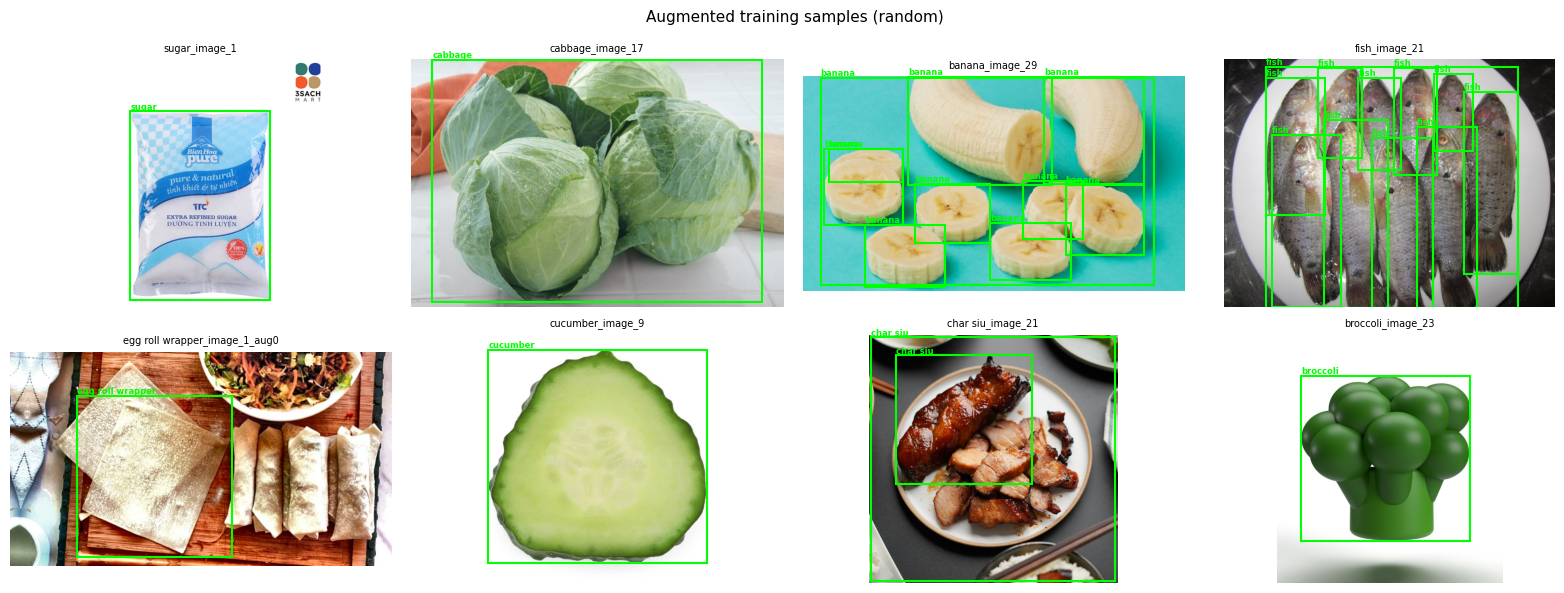

In [10]:
def yolo_to_xyxy(box, w, h):
    cx, cy, bw, bh = box
    return (cx - bw/2)*w, (cy - bh/2)*h, (cx + bw/2)*w, (cy + bh/2)*h

def show_sample_grid(img_dir: Path, lbl_dir: Path, n: int = 8, title=''):
    imgs = sorted(img_dir.glob('*.*'))
    sample = random.sample(imgs, min(n, len(imgs)))
    cols = 4
    rows = math.ceil(len(sample) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = np.array(axes).flatten()
    for ax, img_path in zip(axes, sample):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        lbl = lbl_dir / (img_path.stem + '.txt')
        class_ids, boxes = read_label(lbl)
        ax.imshow(img)
        h, w = img.shape[:2]
        for cls_id, box in zip(class_ids, boxes):
            x1, y1, x2, y2 = yolo_to_xyxy(box, w, h)
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=1.5, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1-4, CLASS_NAMES[cls_id],
                    color='lime', fontsize=6, fontweight='bold')
        ax.set_title(img_path.stem[:30], fontsize=7)
        ax.axis('off')
    for ax in axes[len(sample):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


# Show 8 random augmented training images
show_sample_grid(
    aug_img_dir, aug_lbl_dir,
    n=8, title='Augmented training samples (random)'
)


## 11. Post-augmentation class distribution

Counting aug labels: 0it [00:00, ?it/s]

Class                            Before    After      Δ
--------------------------------------------------------
beef stock                            8       40    +32
egg white                             6       30    +24
rice flour                            9       41    +32


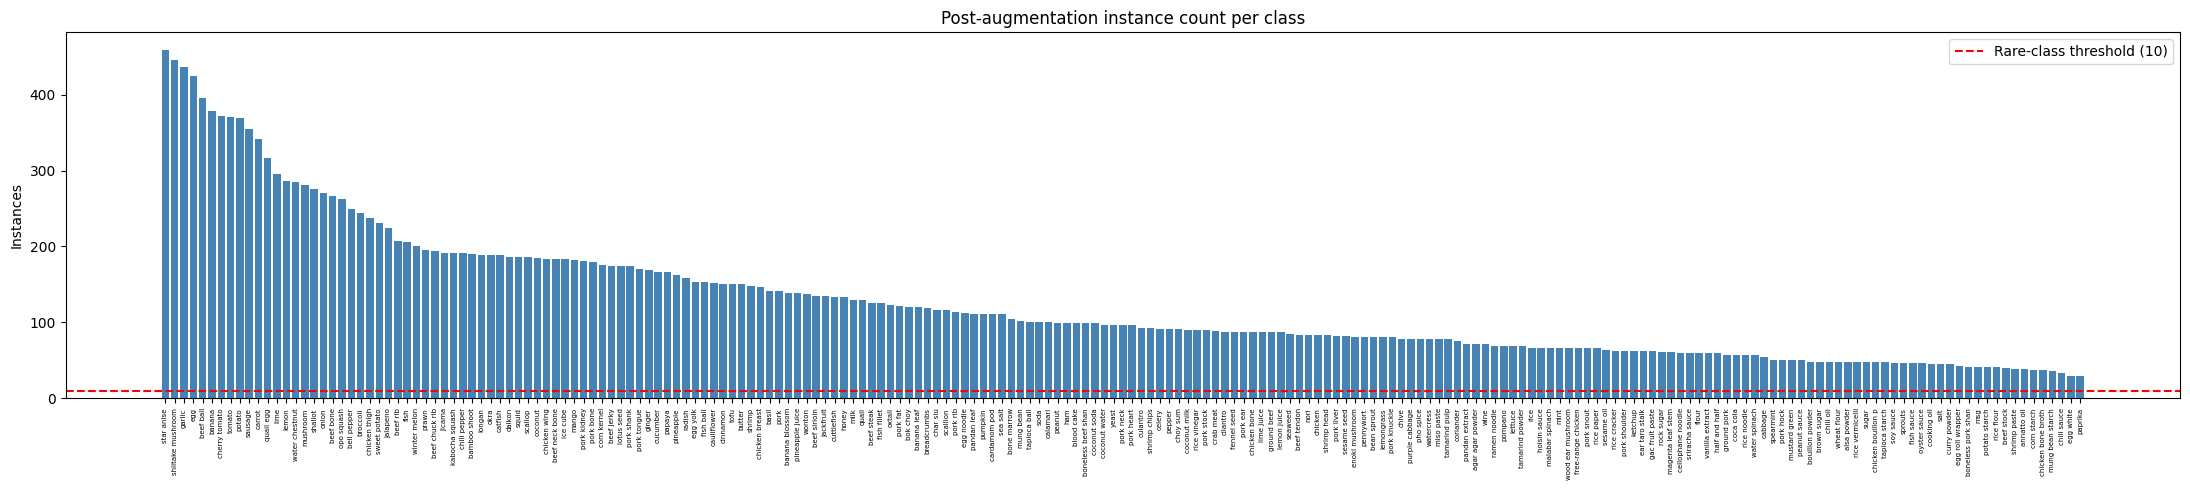

In [11]:
aug_counts: Counter = Counter()
for lbl_file in tqdm(aug_lbl_dir.glob('*.txt'), desc='Counting aug labels'):
    class_ids, _ = read_label(lbl_file)
    for cid in class_ids:
        aug_counts[cid] += 1

orig_counts = class_instance_count   # counted in Cell 7

# Compare rare-class counts before vs after
print(f'{'Class':<30} {'Before':>8} {'After':>8} {'Δ':>6}')
print('-' * 56)
for cid in sorted(rare_classes):
    before = orig_counts.get(cid, 0)
    after  = aug_counts.get(cid, 0)
    name   = CLASS_NAMES[cid]
    print(f'{name:<30} {before:>8} {after:>8} {after-before:>+6}')

# Bar chart — full distribution
sorted_ids = sorted(aug_counts, key=aug_counts.get, reverse=True)
names_s = [CLASS_NAMES[i][:18] for i in sorted_ids]
vals_s  = [aug_counts[i] for i in sorted_ids]

fig, ax = plt.subplots(figsize=(22, 5))
ax.bar(range(len(vals_s)), vals_s, color='steelblue', width=0.8)
ax.set_xticks(range(len(names_s)))
ax.set_xticklabels(names_s, rotation=90, fontsize=5)
ax.axhline(AUG_CFG['rare_class_thresh'], color='red', linestyle='--',
           label=f'Rare-class threshold ({AUG_CFG["rare_class_thresh"]})')
ax.set_title('Post-augmentation instance count per class')
ax.set_ylabel('Instances')
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
# ============================================================================
# DATASET HEALTH CHECK — run before training
# ============================================================================
import random

def check_dataset_health(img_dir: Path, lbl_dir: Path, split: str, sample_n: int = 5):
    imgs = sorted(img_dir.glob('*.*'))
    lbls = sorted(lbl_dir.glob('*.txt'))

    img_stems = {p.stem for p in imgs}
    lbl_stems = {p.stem for p in lbls}

    imgs_no_label  = img_stems - lbl_stems   # images with no label file
    labels_no_img  = lbl_stems - img_stems   # orphaned label files

    # Count total instances across all labels
    total_instances = 0
    empty_labels    = 0
    corrupt_labels  = 0
    for lbl in lbls:
        try:
            ids, boxes = read_label(lbl)
            if not ids:
                empty_labels += 1
            total_instances += len(ids)
        except Exception:
            corrupt_labels += 1

    print(f'\n{"="*55}')
    print(f'  Split          : {split}')
    print(f'{"="*55}')
    print(f'  Images         : {len(imgs)}')
    print(f'  Label files    : {len(lbls)}')
    print(f'  Total instances: {total_instances}')
    print(f'  Avg inst/image : {total_instances / max(len(imgs), 1):.2f}')
    print(f'  Empty labels   : {empty_labels}')
    print(f'  Corrupt labels : {corrupt_labels}')
    print(f'  Images w/o lbl : {len(imgs_no_label)}  {"⚠️  BAD" if imgs_no_label else "✅"}')
    print(f'  Orphan labels  : {len(labels_no_img)}  {"⚠️  BAD" if labels_no_img else "✅"}')

    # Spot-check a few random label files
    print(f'\n  --- {sample_n} random label samples ---')
    for lbl in random.sample(lbls, min(sample_n, len(lbls))):
        ids, boxes = read_label(lbl)
        print(f'  {lbl.name:<45} {len(ids)} instances  classes={ids[:3]}{"..." if len(ids)>3 else ""}')

    # Overall verdict
    healthy = (
        len(imgs) > 0 and
        total_instances > 0 and
        len(imgs_no_label) / max(len(imgs), 1) < 0.05  # allow <5% background
    )
    print(f'\n  Verdict: {"✅ HEALTHY — safe to train" if healthy else "❌ UNHEALTHY — fix before training"}')
    return healthy


# ── Check all three splits ────────────────────────────────────────────────────
train_healthy = check_dataset_health(
    aug_img_dir,
    aug_lbl_dir,
    split='train (augmented)'
)

val_healthy = check_dataset_health(
    AUG_DATASET / 'val'  / 'images',
    AUG_DATASET / 'val'  / 'labels',
    split='val'
)

test_healthy = check_dataset_health(
    AUG_DATASET / 'test' / 'images',
    AUG_DATASET / 'test' / 'labels',
    split='test'
)

# ── Final gate ────────────────────────────────────────────────────────────────
print('\n' + '='*55)
if all([train_healthy, val_healthy, test_healthy]):
    print('  ✅ ALL SPLITS HEALTHY — proceed to training')
else:
    print('  ❌ ONE OR MORE SPLITS FAILED — do NOT train yet')
    print('     Re-run Section 8 (aug loop) and check paths in Section 9.')
print('='*55)


  Split          : train (augmented)
  Images         : 11462
  Label files    : 11450
  Total instances: 26327
  Avg inst/image : 2.30
  Empty labels   : 0
  Corrupt labels : 0
  Images w/o lbl : 0  ✅
  Orphan labels  : 0  ✅

  --- 5 random label samples ---
  water spinach_image_7.txt                     1 instances  classes=[199]
  rice noodle_image_14.txt                      1 instances  classes=[163]
  bone marrow_image_10_aug1.txt                 1 instances  classes=[21]
  sesame oil_image_6_aug1.txt                   1 instances  classes=[174]
  pandan leaf_image_31.txt                      1 instances  classes=[124]

  Verdict: ✅ HEALTHY — safe to train

  Split          : val
  Images         : 651
  Label files    : 651
  Total instances: 1411
  Avg inst/image : 2.17
  Empty labels   : 0
  Corrupt labels : 0
  Images w/o lbl : 0  ✅
  Orphan labels  : 0  ✅

  --- 5 random label samples ---
  bean sprout_image_9.txt                       1 instances  classes=[8]
  bean sprou

## 12. Load YOLOv11 model

In [13]:
model = YOLO(TRAIN_CFG['model'])
print(f'Model : {TRAIN_CFG["model"]} loaded.')

Model : yolo11n.pt loaded.


## 13. Train with offline-augmented data + online YOLO augmentation

In [14]:
print('=' * 80)
print('Starting Training')
print('=' * 80)

results = model.train(
    data = str(DATA_YAML),
    epochs = TRAIN_CFG['epochs'],
    imgsz = TRAIN_CFG['imgsz'],
    batch = TRAIN_CFG['batch'],
    device = TRAIN_CFG['device'],
    workers = TRAIN_CFG['workers'],
    patience = TRAIN_CFG['patience'],
    save = TRAIN_CFG['save'],
    save_period = TRAIN_CFG['save_period'],
    cache = TRAIN_CFG['cache'],
    optimizer = TRAIN_CFG['optimizer'],
    lr0 = TRAIN_CFG['lr0'],
    lrf = TRAIN_CFG['lrf'],
    momentum = TRAIN_CFG['momentum'],
    weight_decay = TRAIN_CFG['weight_decay'],
    warmup_epochs = TRAIN_CFG['warmup_epochs'],
    warmup_momentum = TRAIN_CFG['warmup_momentum'],
    warmup_bias_lr = TRAIN_CFG['warmup_bias_lr'],
    box = TRAIN_CFG['box'],
    cls = TRAIN_CFG['cls'],
    dfl = TRAIN_CFG['dfl'],
    # colour
    hsv_h = TRAIN_CFG['hsv_h'],
    hsv_s = TRAIN_CFG['hsv_s'],
    hsv_v = TRAIN_CFG['hsv_v'],
    # geometry
    degrees = TRAIN_CFG['degrees'],
    translate = TRAIN_CFG['translate'],
    scale = TRAIN_CFG['scale'],
    shear = TRAIN_CFG['shear'],
    perspective = TRAIN_CFG['perspective'],
    flipud = TRAIN_CFG['flipud'],
    fliplr = TRAIN_CFG['fliplr'],
    # mixing / occlusion
    mosaic = TRAIN_CFG['mosaic'],
    mixup = TRAIN_CFG['mixup'],
    copy_paste = TRAIN_CFG['copy_paste'],
    erasing = TRAIN_CFG['erasing'],
    project = str(WEIGHTS_DIR),
    name = TRAIN_CFG['name'],
    exist_ok = True,
    pretrained = True,
    verbose = True,
)

print('\n' + '=' * 80)
print('Training complete!')
print('=' * 80)

Starting Training
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_aug.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.75, hsv_v=0.45, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ingredient_detection_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

libpng warning: iCCP: extra compressed data


      1/120      3.01G      1.419      5.251      1.794         95        640: 22% ━━╸───────── 156/716 2.3it/s 1:21<4:02

libpng warning: eXIf: duplicate


      1/120      3.01G      1.394      5.241      1.775         89        640: 25% ━━━───────── 182/716 2.4it/s 1:32<3:40

...

    120/120      3.02G     0.6803     0.5094      1.224         30        640: 84% ━━━━━━━━━━── 604/716 4.5it/s 2:39<24.9s

libpng warning: iCCP: profile 'icc': 0h: PCS illuminant is not D50


    120/120      3.03G     0.6826     0.5111      1.224         22        640: 100% ━━━━━━━━━━━━ 716/716 3.8it/s 3:08


libpng warning: iCCP: profile 'icc': 0h: PCS illuminant is not D50


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.4it/s 4.8s
                   all        650       1409      0.594      0.631      0.668      0.553

120 epochs completed in 7.264 hours.
Optimizer stripped from /kaggle/working/weights/ingredient_detection_aug/weights/last.pt, 5.7MB
Optimizer stripped from /kaggle/working/weights/ingredient_detection_aug/weights/best.pt, 5.7MB

Validating /kaggle/working/weights/ingredient_detection_aug/weights/best.pt...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,680,009 parameters, 0 gradients, 6.8 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 3.8it/s 5.5s
                   all        650       1409      0.593      0.633      0.668      0.553
      agar agar powder          4          4      0.529       0.75      0.656      0.321
    

## 14. Validate

In [15]:
metrics = model.val()
print(f'\nValidation Results')
print(f'mAP50: {metrics.box.map50:.4f}')
print(f'mAP50-95: {metrics.box.map:.4f}')
print(f'Precision: {metrics.box.mp:.4f}')
print(f'Recall: {metrics.box.mr:.4f}')

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,680,009 parameters, 0 gradients, 6.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 144.8±102.6 MB/s, size: 177.5 KB)
val: Scanning /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/labels... 650 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 651/651 316.1it/s 2.1s
val: /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/images/tomato_image_16.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/images/tomato_image_16.jpg'
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 6.1it/s 6.7s
                 

## 15. Test inference on a sample image

In [16]:
test_dir = DATASET_PATH / data_cfg['test']
test_imgs = sorted(test_dir.glob('*.*'))
if test_imgs:
    sample = random.choice(test_imgs)
    results_inf = model.predict(
        source=str(sample),
        conf=0.25,
        iou=0.45,
        save=True,
        show=False,
    )
    for r in results_inf:
        print(f'Image: {sample.name}')
        for box in r.boxes:
            cls  = int(box.cls[0])
            conf = float(box.conf[0])
            print(f'  {CLASS_NAMES[cls]:<30}  conf={conf:.2f}')
else:
    print('No test images found.')


image 1/1 /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/test/images/water spinach_image_6.webp: 480x640 1 water spinach, 54.6ms
Speed: 2.2ms preprocess, 54.6ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /kaggle/working/runs/detect/predict
Image: water spinach_image_6.webp
  water spinach                   conf=0.67


## 16. Save best weights

In [17]:
best = WEIGHTS_DIR / TRAIN_CFG['name'] / 'weights' / 'best_aug.pt'
model.save(str(best))
print(f'Best weights: {best}')
print(f'Last weights: {best.parent / "last.pt"}')

Best weights: /kaggle/working/weights/ingredient_detection_aug/weights/best_aug.pt
Last weights: /kaggle/working/weights/ingredient_detection_aug/weights/last.pt
